# The Fundamentals of Machine Learning

Fundamentally, machine learning is all about training to optimize a constraint or cost. This cost $c$ defines a penalty each time the model makes an incorrect classification or prediction versus the true value.

The two standard problems in machine learning are regression (generating a value based on inputs) and classification (predicting a category based on inputs). The standard notation given is $X$ for the input variables and $y$ for the true values (assuming we have the true values/supervised case)

## Linear Regression

One of the simplest "machine learning" models is linear regression. For each row that we are trying to predict a value, its specific inputs are $\vec{x} \in X $. Linear regression gives us two controls at our disposal: a vector $\vec{w}$ that contains the weights for each of the inputs in $x$, and a scalar bias $b$. These two controls are used to determine the final predicted value (we use $\hat{y}$ to denote predicted value):

$$
\hat{y} = \vec{w} \cdot \vec{x} + b
$$

Linear regression uses the mean-squared error (MSE) cost function. If there are $m$ tested inputs, the cost is given as:

$$
cost = \frac{1}{m} \sum_{i = 1}^{m}{(\hat{y} - y)^2}
$$

## Logistic Regression

One of the simplest machine learning models for classification is the logistic regression. Fundamentally, it uses the linear regression, with the same weights/bias, just with a transform that turns it into a classification problem. It is based on the sigmoid function:
$$
z = \vec{w} \cdot \vec{x} + b
$$
$$
\hat{y} = \frac{1}{1+e^{-z}}
$$

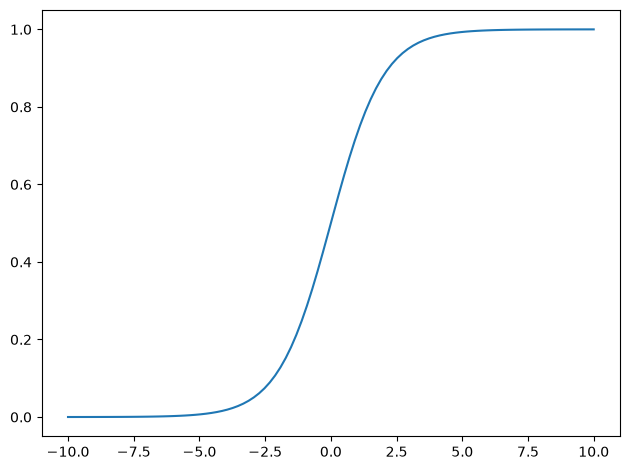

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

plt.plot(np.linspace(-10, 10, 100),sigmoid(np.linspace(-10, 10, 100)))
plt.tight_layout()
plt.show()


Logistic regression does not use MSE, but the Log Loss (Binary Cross-Entropy) function. For a simple example, it is given as:

$$
-[y\log(\hat{y}) + (1-y)\log(1-\hat{y})]
$$

While it looks complicated, it is just the combination of two cases. 
- When the true value is 1, only the first part matters because $1-y$ cancels out, and it simplifies to $-\log(\hat{y})$. 
- When the true value is 0, only the second part matters because $y$ cancels out, and it simplifies to $-\log(1-\hat{y})$

Let's observe the negative log graph from 0 to 1.

C:\Users\Alexander Xu\AppData\Local\Temp\ipykernel_4784\2769113068.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.linspace(0, 1, 100), -np.log(np.linspace(0, 1, 100)))


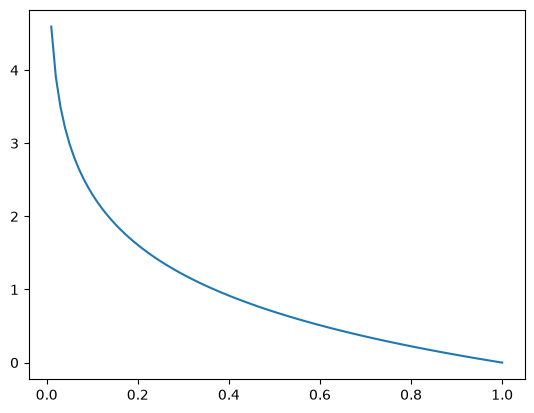

In [5]:
plt.plot(np.linspace(0, 1, 100), -np.log(np.linspace(0, 1, 100)))
plt.show()

The cost grows exponentially the closer x is to 0. Thus:
- when the true value is 1, the cost $-log(\hat{y})$ will grow exponentially larger as our predicted probability value gets closer to 0
- when the true value is 0, $1 - \hat{y}$ becomes closer to 0 as our predicted probability increases toward 1, so the cost $-log(1 - \hat{y})$ will grow as the probability increases toward 1.

We average all the examples to obtain the final cost function:
$$
cost = \frac{1}{m} \sum_{i=1}^{m} \left[y_i\log(\hat{y_i}) + (1-y_i)\log(1-\hat{y_i})\right]
$$

We can expand logistic regression from two cases to an arbitrary number of cases by using the softmax function instead of the sigmoid function. The probability of category $1 \leq k \leq n$ for a single example $i$ is given as: 

$$
\hat{y}_{i,k} = softmax(z_{i,k}) = \frac{e^{z_{i,k}}}{\sum_{j=0}^n e^{z_{i, j}}}
$$

where $z$ is the linear regression (logit) results. Assuming $n$ is the number of categories, the cost function is then:

$$
cost = \frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{n}{y_{i,j}\log(\hat{y}_{i,j})}
$$


## Gradient Descent

Now that we have introduced some basic models and defined cost functions, we can now analyze the specific mechanism to optimize for the cost function. We want to optimize for the cost function by manipulating the weights and biased we introduced, so it is necessary to observe how each weight affects the final cost. We find this effect by taking the partial derivative of cost $J$ with respect to some weight $w_i$:

$$
\frac{\partial J}{\partial w_i}
$$

If gradient is positive, then increasing weight $w_i$ increases $Q$, so we decrease. If gradient is negative, then increasing weight $w_i$ decreases $Q$, so we increase. Thus, we change $w_i$ in the opposite direction of gradient according to some scaled factor of the gradient. In other words, we are looking to update $w_i$ using the following procedure:

$$
w_{i, new} = w_{i, old} - c \cdot \frac{\partial J}{\partial w_i}
$$

The constant $c$ is called the learning-rate, as it controls how fast we want to update a variable (a.k.a how fast it'll learn or converge).



We can expand this expression to obtain the standard expression for gradient descent for all weights:

$$
W_{new} = W_{old} - c \cdot \nabla J(W_{old})
$$

Now, the challenge is to find the value of $\frac{\partial J}{\partial w_i}$, because it is often the case that $w_i$ is nested within many functions inside of $J$.

## Back-Propagation

The purpose of back-propagation is to compute how the final cost changes with respect to each model parameter. For a weight $w_i$, the quantity we want is:

$$
\frac{\partial J}{\partial w_i}
$$

where $J$ represents the final cost or loss.

In simple models, this derivative may be easy to compute directly. But in more complex models, the final output is produced through a long chain of nested functions. Back-propagation is an efficient way to apply the chain rule through this entire sequence.

For example, in logistic regression, the computation can be written as a sequence of steps:

$$
z = w \cdot x + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}
$$

$$
J = L(\hat{y}, y)
$$

where $L$ is the cross-entropy loss function.

So the full computation is:

$$
x \rightarrow z \rightarrow \hat{y} \rightarrow J
$$

or, using function notation:

$$
J = L(\sigma(w \cdot x + b), y)
$$

More generally, many models can be viewed as a composition of functions:

$$
J = f_n(f_{n-1}(\cdots f_2(f_1(w_i)) \cdots ))
$$

Here, $w_i$ first influences the computation through $f_1$, and that effect is passed forward through each later function until it reaches the final cost $J$.


The key to back-propagation is the chain-rule. Applying the chain-rule to the function composition above, we obtain:

$$
\frac{\partial J}{\partial w_i} = \frac{\partial J}{\partial f_n} \cdot \frac{\partial f_n}{\partial f_{n-1}} \cdots \frac{\partial f_2}{\partial f_1} \cdot \frac{\partial f_1}{\partial w_i}
$$

This technique is traditionally made very efficient by caching necessary values to compute the partial derivatives. One other thing to note is that if multiple functions of the same variable are applied in the final cost (e.g $Q = H(f, g, h)$ where $f, g, h$ are functions of $x$), and we know $\frac{\partial J}{\partial f}, \frac{\partial J}{\partial g}, \frac{\partial J}{\partial h}$ (from backprop), then we have the following property:

$$
\frac{\partial J}{\partial x} = \frac{\partial J}{\partial f} \cdot \frac{\partial f}{\partial x} + \frac{\partial J}{\partial g}\cdot \frac{\partial g}{\partial x} + \frac{\partial J}{\partial h} \cdot \frac{\partial h}{\partial x}
$$
